In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import seaborn as sns
from matplotlib.colors import ListedColormap

# Collect proportions from each file
all_data = []

for file in sorted(glob.glob("../datasets/*/*_ids.csv")):
    df = pd.read_csv(file)

    df['method'] = df['method'].mask(
        df['method'].isna() & df['openalex_id'].isna(), "Not found"
    ).mask(
        df['method'].isna() & df['openalex_id'].notna(), "Provided"
    )

    counts = df['method'].value_counts(normalize=True)  # normalized → proportions
    counts.name = os.path.basename(file)
    all_data.append(counts)

# Combine into one DataFrame
proportions_df = pd.DataFrame(all_data).fillna(0)

# Sort columns (methods) alphabetically for consistency
proportions_df = proportions_df.reindex(sorted(proportions_df.columns), axis=1)

colors = sns.color_palette("tab20", n_colors=len(proportions_df.columns))
cmap = ListedColormap(colors)

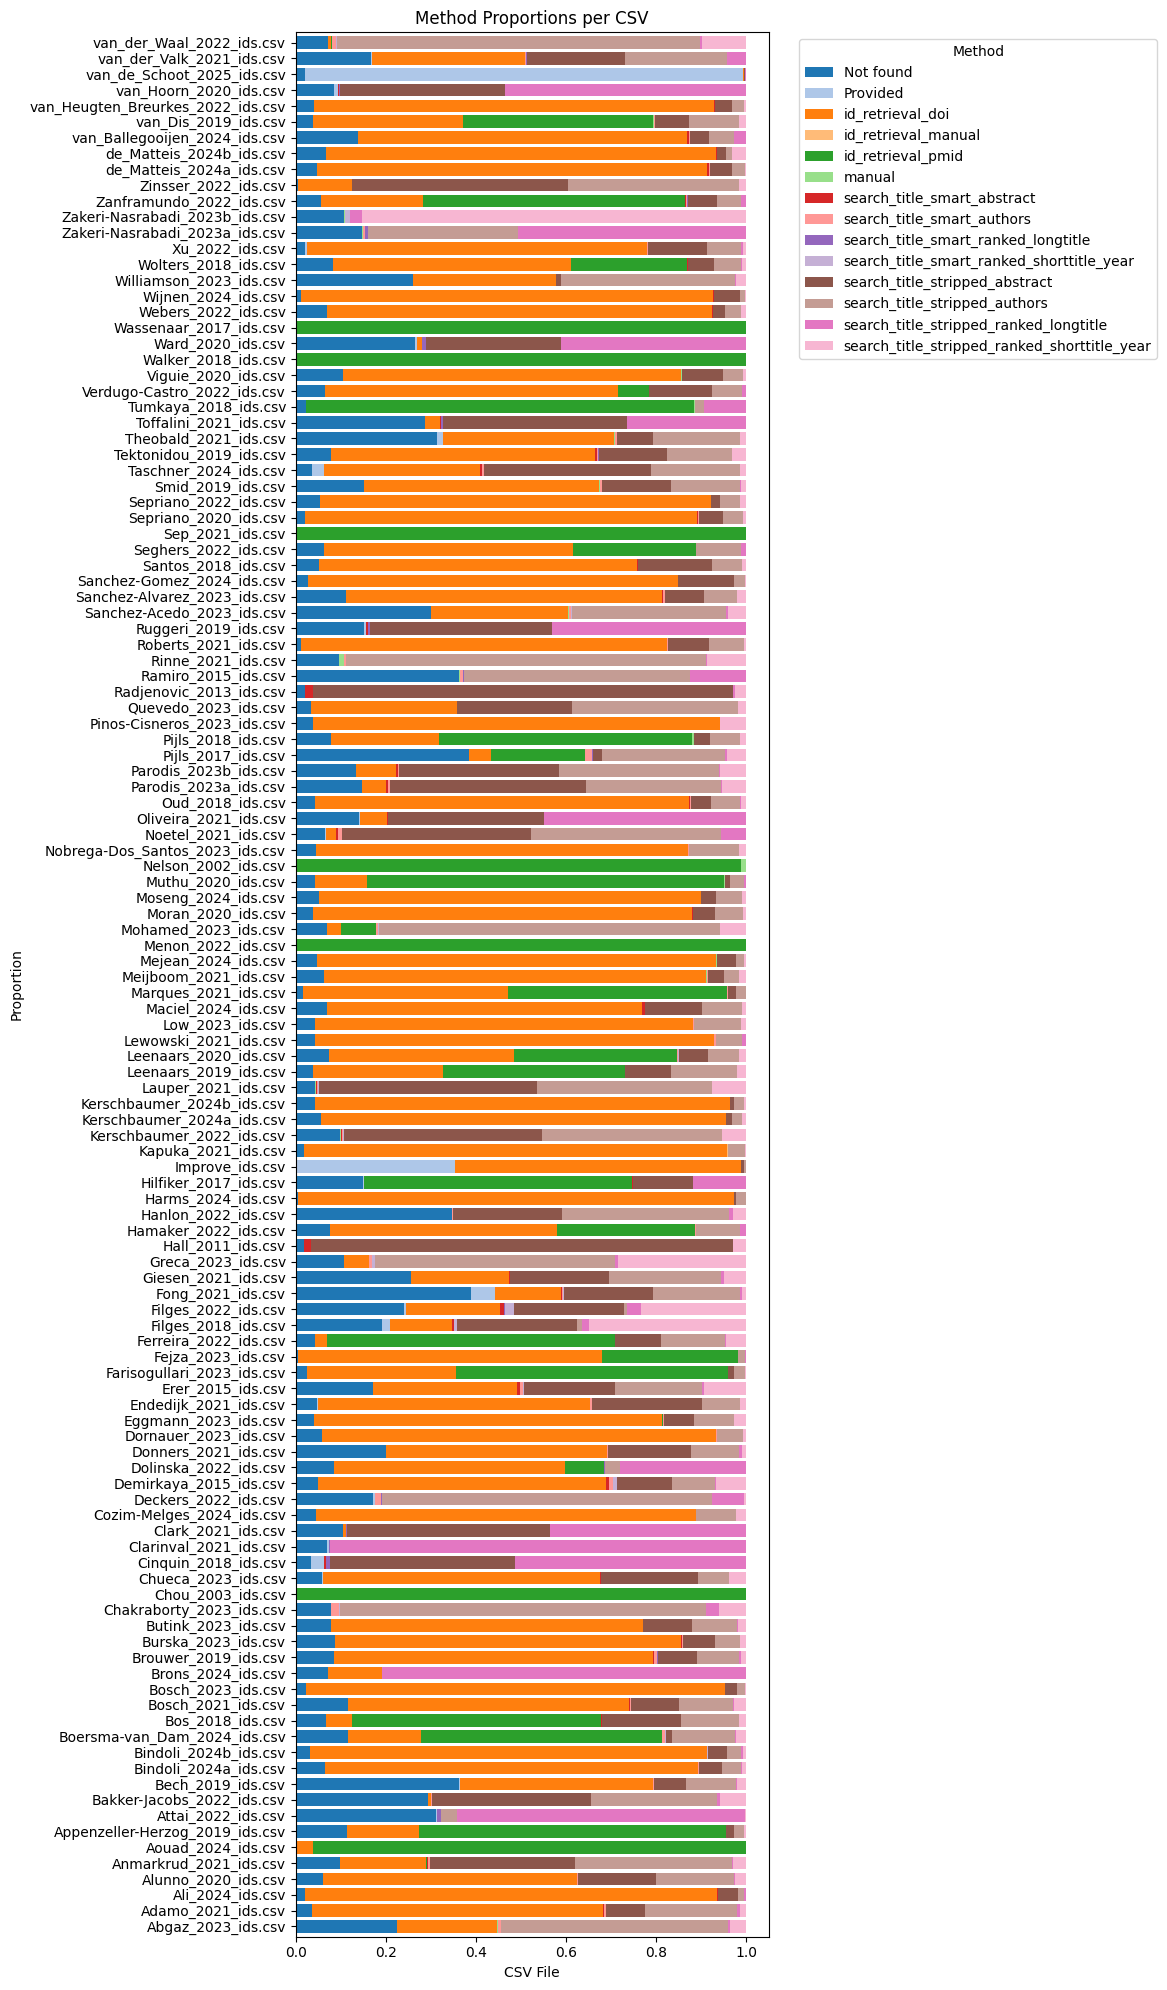

In [2]:
# Plot stacked bar chart
ax = proportions_df.plot(
    kind='barh',
    stacked=True,
    figsize=(12, 20),
    width=0.8,
    colormap=cmap
)

plt.ylabel("Proportion")
plt.xlabel("CSV File")
plt.title("Method Proportions per CSV")
plt.legend(title="Method", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


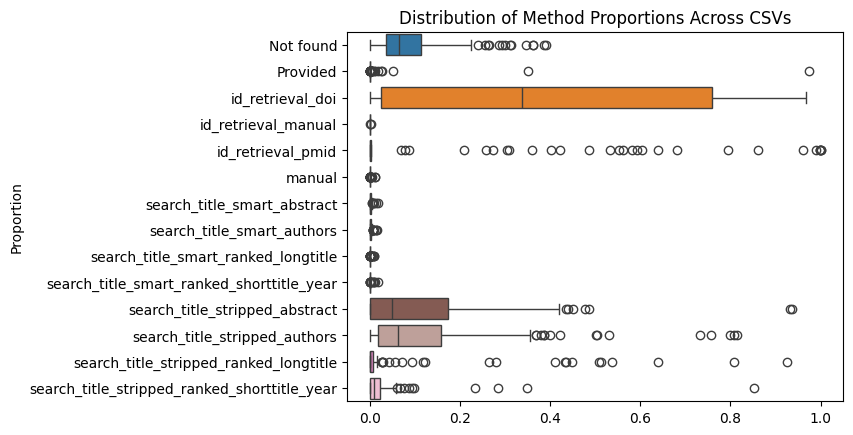

In [3]:
sns.boxplot(data=proportions_df, orient="h", palette=colors, legend=False)
plt.ylabel("Proportion")
plt.title("Distribution of Method Proportions Across CSVs")
plt.show()

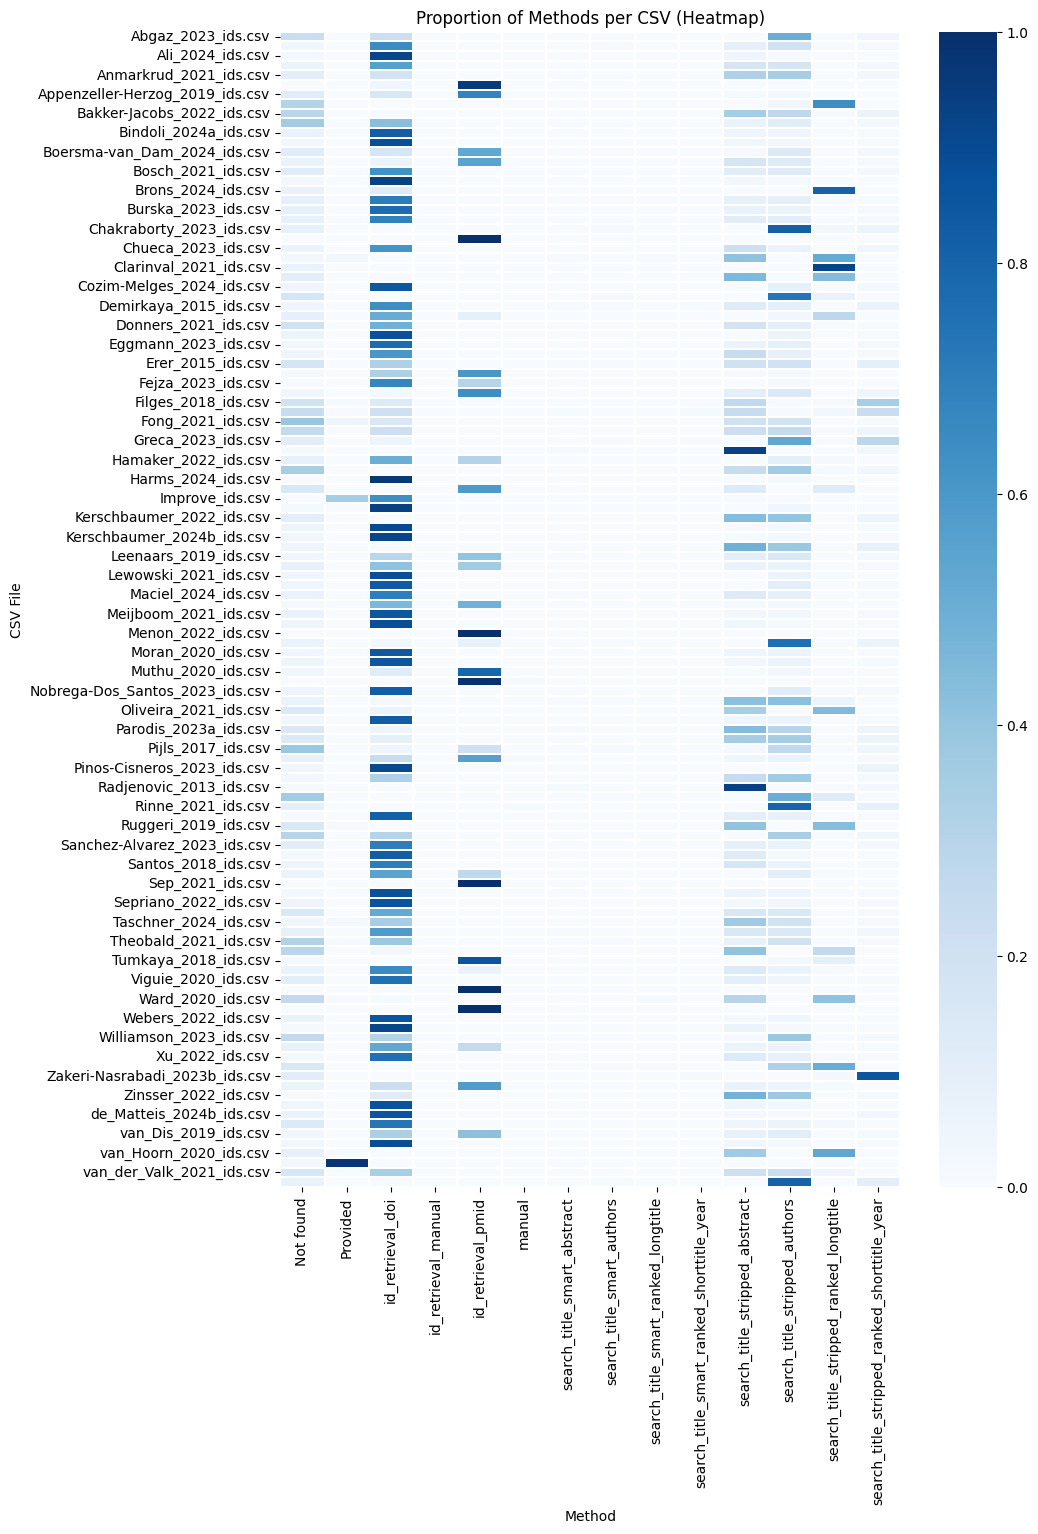

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 15))
sns.heatmap(proportions_df, cmap="Blues", linewidths=0.2)
plt.xlabel("Method")
plt.ylabel("CSV File")
plt.title("Proportion of Methods per CSV (Heatmap)")
plt.show()